# Notebook 07 – Feature Importance Analysis

## Objective

While predictive performance is important, understanding **why** a model makes its predictions is equally valuable. Feature importance analysis provides insight into which meteorological and engineered variables contribute most to forecasting future temperatures.

This notebook evaluates feature importance across multiple tree-based ensemble models to improve model interpretability and identify the variables that drive forecasting performance.

## Goals

- Load the engineered weather dataset.
- Recreate the forecasting dataset.
- Train the best-performing tree-based forecasting models.
- Extract feature importance from each model.
- Compare feature rankings across algorithms.
- Identify the variables that contribute most to temperature forecasting.

In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

In [6]:
import sys
from pathlib import Path

# Add the project root to Python path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

In [7]:
from src.models.random_forest import (
    train_random_forest,
)

from src.models.xgboost_model import (
    train_xgboost,
)

from src.models.lightgbm_model import (
    train_lightgbm,
)

from src.models.catboost_model import (
    train_catboost,
)

In [8]:
DATA_PATH = Path("../data/processed/weather_engineered.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,wind_mph,wind_kph,wind_degree,...,wind_direction_WNW,wind_direction_WSW,moon_phase_First Quarter,moon_phase_Full Moon,moon_phase_Last Quarter,moon_phase_New Moon,moon_phase_Waning Crescent,moon_phase_Waning Gibbous,moon_phase_Waxing Crescent,moon_phase_Waxing Gibbous
0,Washington Park,46.60,-120.49,America/Los_Angeles,1715849100,2024-05-16 01:45:00,-0.579370,4.3,-0.734996,220,...,0,0,0,0,0,0,0,0,0,1
1,San Juan,9.97,-84.08,America/Costa_Rica,1715849100,2024-05-16 02:45:00,-0.047178,2.2,-1.135403,10,...,0,0,0,0,0,0,0,0,0,1
2,Mexico City,19.43,-99.13,America/Mexico_City,1715849100,2024-05-16 02:45:00,-0.068900,6.7,-0.234487,212,...,0,0,0,0,0,0,0,0,0,1
3,San Salvador,13.71,-89.20,America/El_Salvador,1715849100,2024-05-16 02:45:00,0.495874,2.2,-1.135403,182,...,0,0,0,0,0,0,0,0,0,1
4,Guatemala City,14.62,-90.53,America/Guatemala,1715849100,2024-05-16 02:45:00,-0.155789,13.6,1.166937,190,...,0,0,0,0,0,0,0,0,0,1


In [9]:
print(f"Rows: {df.shape[0]:,}")

print(f"Columns: {df.shape[1]}")

df.info()

Rows: 151,827
Columns: 334
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151827 entries, 0 to 151826
Columns: 334 entries, location_name to moon_phase_Waxing Gibbous
dtypes: float64(21), int64(306), object(7)
memory usage: 386.9+ MB


In [10]:
forecast_df = df.copy()

forecast_df["last_updated"] = pd.to_datetime(
    forecast_df["last_updated"]
)

forecast_df = forecast_df.sort_values(
    "last_updated"
)

In [11]:
forecast_df["future_temperature"] = (
    forecast_df
    .groupby("location_name")["temperature_celsius"]
    .shift(-1)
)

In [12]:
forecast_df = forecast_df.dropna(
    subset=["future_temperature"]
)

forecast_df.shape

(151559, 335)

In [13]:
forecast_df = forecast_df.drop(
    columns=[
        "location_name",
        "timezone",
        "sunrise",
        "sunset",
        "moonrise",
        "moonset",
    ]
)

In [14]:
target = "future_temperature"

X = forecast_df.drop(
    columns=[
        target,
        "last_updated",
    ]
)

y = forecast_df[target]

In [15]:
X.shape

X.select_dtypes(include="object").columns

Index([], dtype='object')

## Chronological Train/Test Split

To maintain consistency with the forecasting workflow developed in Notebook 06, the dataset is divided chronologically rather than randomly.

The first 80% of observations are used for model training, while the remaining 20% represent unseen future observations used for evaluation. This approach prevents look-ahead bias and better simulates a real-world forecasting scenario.

In [16]:
split_index = int(
    len(forecast_df) * 0.80
)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 121247
Testing samples: 30312


In [17]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns

X_train_numeric = X_train[numeric_features]

X_test_numeric = X_test[numeric_features]

print("Number of numeric features:", len(numeric_features))

Number of numeric features: 327


In [18]:
random_forest_model, random_forest_metrics, random_forest_predictions = (
    train_random_forest(
        X_train_numeric,
        y_train,
        X_test_numeric,
        y_test,
    )
)

random_forest_metrics

MAE     0.180383
MSE     0.062757
RMSE    0.250513
R2      0.935904
dtype: float64

In [19]:
xgboost_model, xgboost_metrics, xgboost_predictions = (
    train_xgboost(
        X_train_numeric,
        y_train,
        X_test_numeric,
        y_test,
    )
)

xgboost_metrics

MAE     0.170861
MSE     0.057207
RMSE    0.239179
R2      0.941572
dtype: float64

In [20]:
lightgbm_model, lightgbm_metrics, lightgbm_predictions = (
    train_lightgbm(
        X_train_numeric,
        y_train,
        X_test_numeric,
        y_test,
    )
)

lightgbm_metrics

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4949
[LightGBM] [Info] Number of data points in the train set: 121247, number of used features: 279
[LightGBM] [Info] Start training from score 0.044943


MAE     0.169079
MSE     0.056685
RMSE    0.238087
R2      0.942105
dtype: float64

In [21]:
catboost_model, catboost_metrics, catboost_predictions = (
    train_catboost(
        X_train_numeric,
        y_train,
        X_test_numeric,
        y_test,
    )
)

catboost_metrics

MAE     0.170507
MSE     0.058122
RMSE    0.241085
R2      0.940637
dtype: float64

## Random Forest Feature Importance

Random Forest estimates feature importance by measuring the average reduction in prediction error contributed by each variable across all decision trees in the ensemble.

Higher importance scores indicate variables that contribute more significantly to temperature forecasting.

In [22]:
rf_importance = pd.DataFrame(
    {
        "Feature": X_train_numeric.columns,
        "Importance": random_forest_model.feature_importances_,
    }
)

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False,
)

rf_importance.head(20)

,Feature,Importance
3,temperature_celsius,0.930263
0,latitude,0.004011
2,last_updated_epoch,0.003673
11,humidity,0.003303
6,wind_degree,0.003139
19,air_quality_Ozone,0.002967
8,pressure_in,0.002861
18,air_quality_Carbon_Monoxide,0.002857
15,uv_index,0.002760
20,air_quality_Nitrogen_dioxide,0.002703


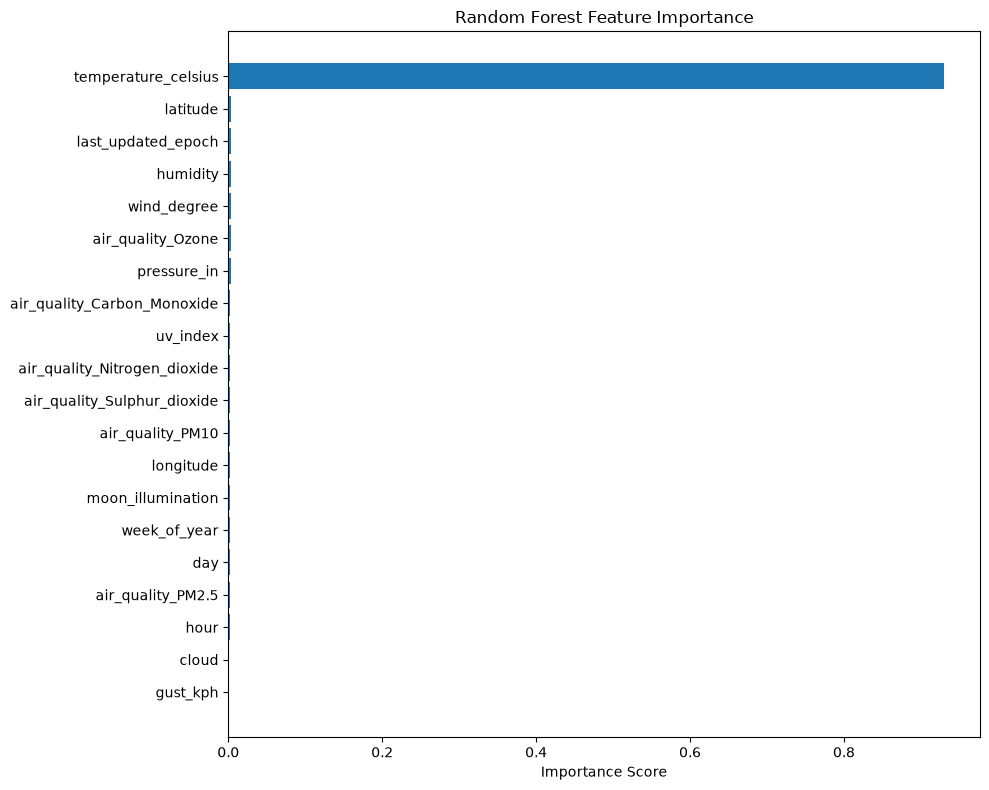

In [23]:
plt.figure(figsize=(10,8))

plt.barh(
    rf_importance["Feature"][:20][::-1],
    rf_importance["Importance"][:20][::-1],
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

## XGBoost Feature Importance

XGBoost computes feature importance based on each feature's contribution to reducing the model's objective function during boosting.

These importance values identify which engineered variables contribute most to improving forecasting accuracy.

In [24]:
xgb_importance = pd.DataFrame(
    {
        "Feature": X_train_numeric.columns,
        "Importance": xgboost_model.feature_importances_,
    }
)

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False,
)

xgb_importance.head(20)

,Feature,Importance
3,temperature_celsius,0.754162
227,country_Uganda,0.004894
273,condition_text_Moderate or heavy rain with thu...,0.004285
62,country_Burundi,0.004030
30,hour,0.003850
0,latitude,0.003761
263,condition_text_Light rain,0.003631
209,country_Swaziland,0.003615
236,country_Venezuela,0.003436
8,pressure_in,0.003413


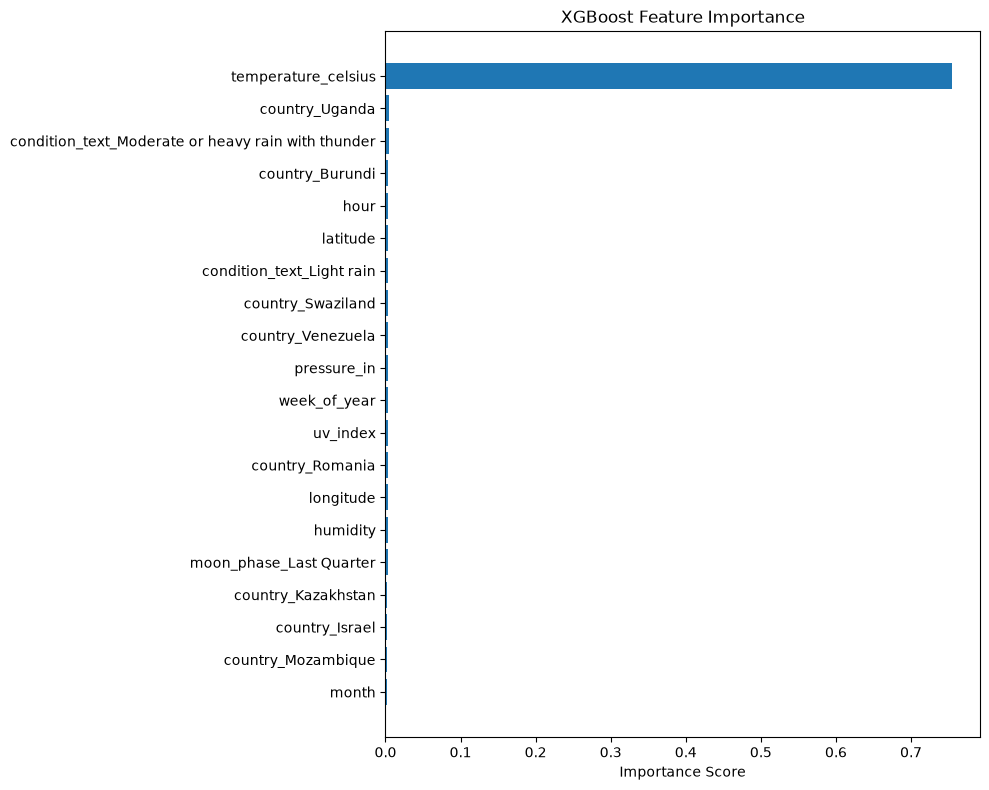

In [25]:
plt.figure(figsize=(10,8))

plt.barh(
    xgb_importance["Feature"][:20][::-1],
    xgb_importance["Importance"][:20][::-1],
)

plt.title("XGBoost Feature Importance")

plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

## LightGBM Feature Importance

LightGBM computes feature importance by evaluating how frequently and effectively variables are used to split decision trees throughout the boosting process.

Features with larger importance values contribute more strongly to forecasting performance.

In [26]:
lgb_importance = pd.DataFrame(
    {
        "Feature": X_train_numeric.columns,
        "Importance": lightgbm_model.feature_importances_,
    }
)

lgb_importance = lgb_importance.sort_values(
    by="Importance",
    ascending=False,
)

lgb_importance.head(20)

,Feature,Importance
3,temperature_celsius,573
0,latitude,329
11,humidity,241
1,longitude,206
8,pressure_in,206
2,last_updated_epoch,164
15,uv_index,135
32,week_of_year,133
6,wind_degree,98
30,hour,96


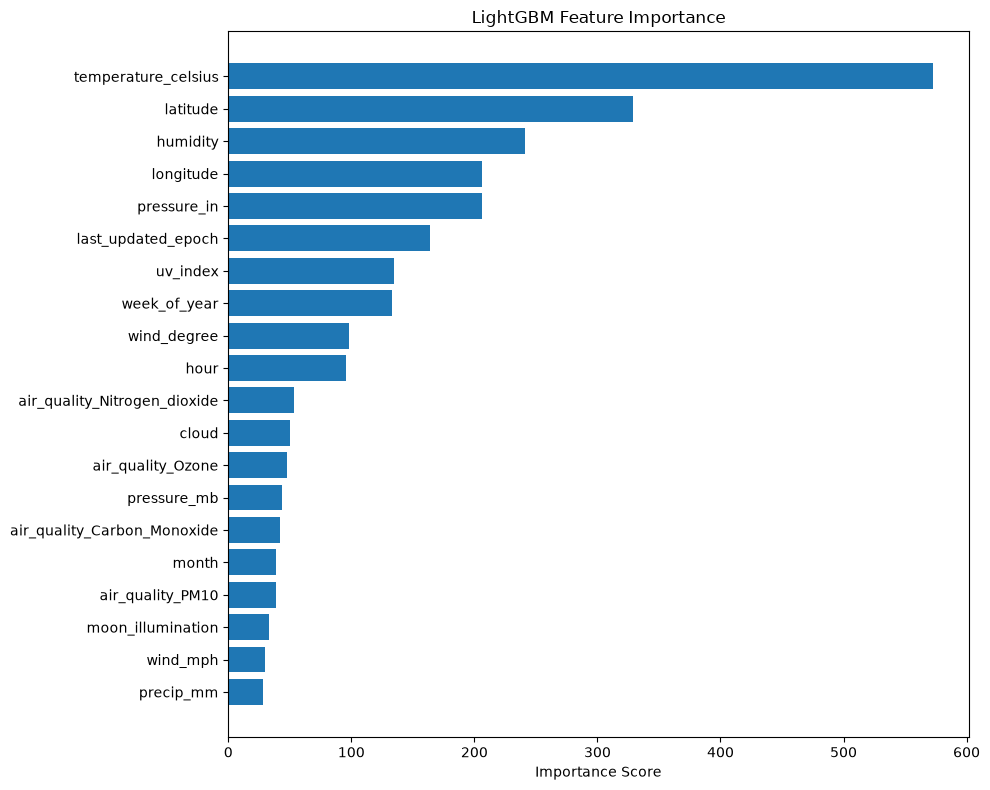

In [27]:
plt.figure(figsize=(10,8))

plt.barh(
    lgb_importance["Feature"][:20][::-1],
    lgb_importance["Importance"][:20][::-1],
)

plt.title("LightGBM Feature Importance")

plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

## CatBoost Feature Importance

CatBoost estimates feature importance by measuring the contribution of each variable to reducing prediction error throughout the boosting process.

The resulting importance scores provide additional insight into the variables most influential for short-term weather forecasting.

In [28]:
cat_importance = pd.DataFrame(
    {
        "Feature": X_train_numeric.columns,
        "Importance": catboost_model.feature_importances_,
    }
)

cat_importance = cat_importance.sort_values(
    by="Importance",
    ascending=False,
)

cat_importance.head(20)

,Feature,Importance
3,temperature_celsius,91.983187
0,latitude,2.132988
8,pressure_in,0.938355
11,humidity,0.926678
15,uv_index,0.834123
1,longitude,0.464418
28,month,0.382709
30,hour,0.380619
32,week_of_year,0.271722
2,last_updated_epoch,0.244004


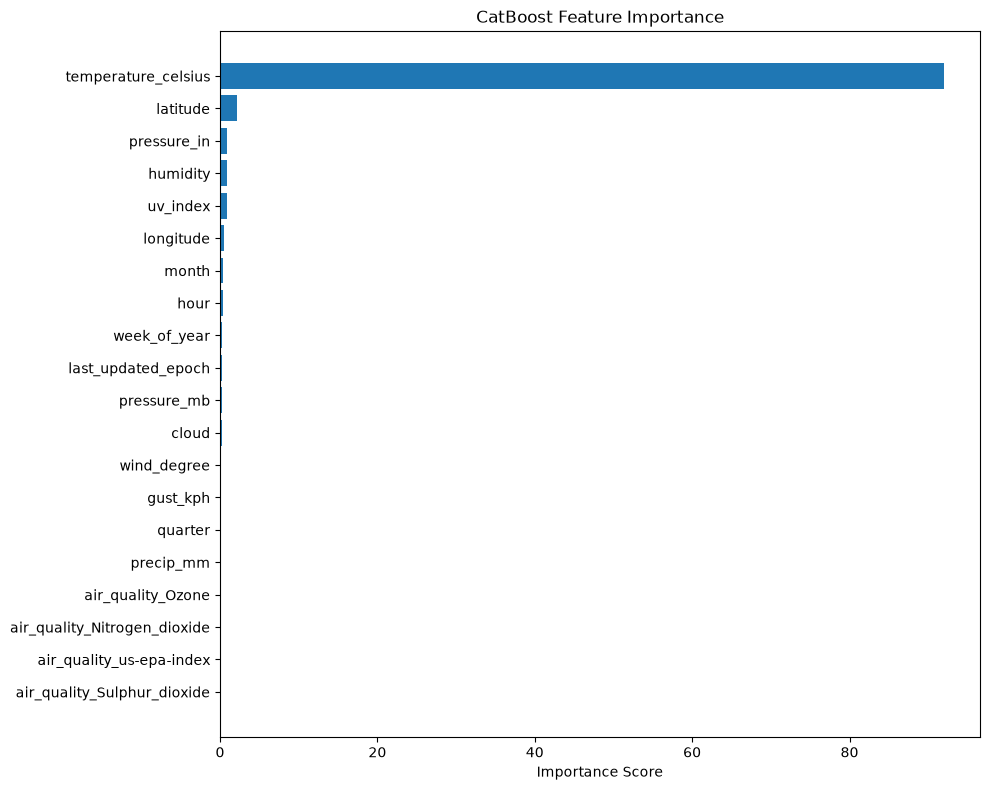

In [29]:
plt.figure(figsize=(10,8))

plt.barh(
    cat_importance["Feature"][:20][::-1],
    cat_importance["Importance"][:20][::-1],
)

plt.title("CatBoost Feature Importance")

plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

## Feature Importance Comparison

Although each ensemble algorithm calculates feature importance differently, comparing their rankings provides valuable insight into the variables that consistently influence forecasting performance.

Features that appear among the most important variables across multiple models can be considered robust predictors of future temperature.

In [30]:
rf_top20 = rf_importance.head(20).copy()
rf_top20["Model"] = "Random Forest"

xgb_top20 = xgb_importance.head(20).copy()
xgb_top20["Model"] = "XGBoost"

lgb_top20 = lgb_importance.head(20).copy()
lgb_top20["Model"] = "LightGBM"

cat_top20 = cat_importance.head(20).copy()
cat_top20["Model"] = "CatBoost"

In [31]:
importance_comparison = pd.concat(
    [
        rf_top20,
        xgb_top20,
        lgb_top20,
        cat_top20,
    ],
    ignore_index=True,
)

importance_comparison.head()

,Feature,Importance,Model
0,temperature_celsius,0.930263,Random Forest
1,latitude,0.004011,Random Forest
2,last_updated_epoch,0.003673,Random Forest
3,humidity,0.003303,Random Forest
4,wind_degree,0.003139,Random Forest


In [32]:
feature_frequency = (
    importance_comparison["Feature"]
    .value_counts()
    .reset_index()
)

feature_frequency.columns = [
    "Feature",
    "Appearances",
]

feature_frequency

,Feature,Appearances
0,temperature_celsius,4
1,longitude,4
2,humidity,4
3,latitude,4
4,hour,4
5,pressure_in,4
6,week_of_year,4
7,uv_index,4
8,month,3
9,cloud,3


In [33]:
feature_frequency[
    feature_frequency["Appearances"] == 4
]

,Feature,Appearances
0,temperature_celsius,4
1,longitude,4
2,humidity,4
3,latitude,4
4,hour,4
5,pressure_in,4
6,week_of_year,4
7,uv_index,4


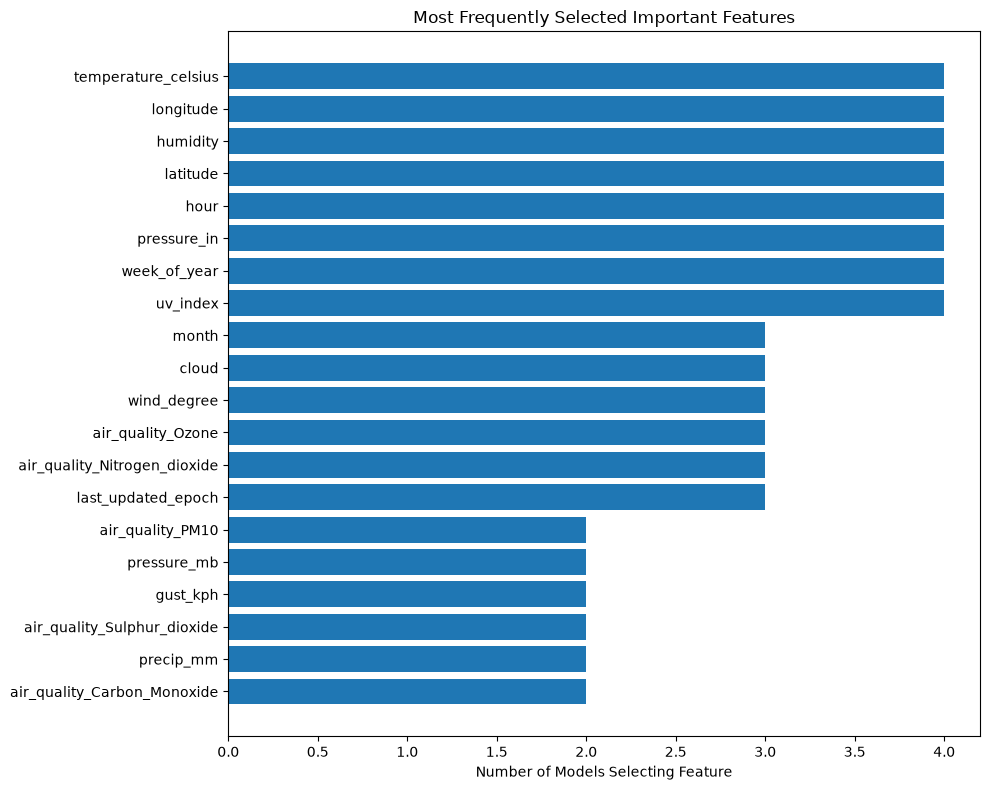

In [34]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_frequency["Feature"][:20][::-1],
    feature_frequency["Appearances"][:20][::-1],
)

plt.title(
    "Most Frequently Selected Important Features"
)

plt.xlabel(
    "Number of Models Selecting Feature"
)

plt.tight_layout()

plt.show()

In [35]:
combined_importance = (
    rf_importance
    .merge(
        xgb_importance,
        on="Feature",
        suffixes=("_RF", "_XGB"),
    )
    .merge(
        lgb_importance,
        on="Feature",
    )
    .merge(
        cat_importance,
        on="Feature",
        suffixes=("_LGB", "_CAT"),
    )
)

combined_importance.columns = [
    "Feature",
    "RF",
    "XGB",
    "LGB",
    "CAT",
]

combined_importance["Average Importance"] = (
    combined_importance[
        ["RF", "XGB", "LGB", "CAT"]
    ].mean(axis=1)
)

combined_importance = combined_importance.sort_values(
    by="Average Importance",
    ascending=False,
)

combined_importance.head(20)

,Feature,RF,XGB,LGB,CAT,Average Importance
0,temperature_celsius,0.930263,0.754162,573,91.983187,166.666903
1,latitude,0.004011,0.003761,329,2.132988,82.785190
3,humidity,0.003303,0.002796,241,0.926678,60.483194
6,pressure_in,0.002861,0.003413,206,0.938355,51.736157
12,longitude,0.002387,0.003030,206,0.464418,51.617459
2,last_updated_epoch,0.003673,0.001649,164,0.244004,41.062331
8,uv_index,0.002760,0.003318,135,0.834123,33.960050
14,week_of_year,0.002079,0.003325,133,0.271722,33.319282
4,wind_degree,0.003139,0.001560,98,0.124360,24.532265
17,hour,0.001571,0.003850,96,0.380619,24.096510


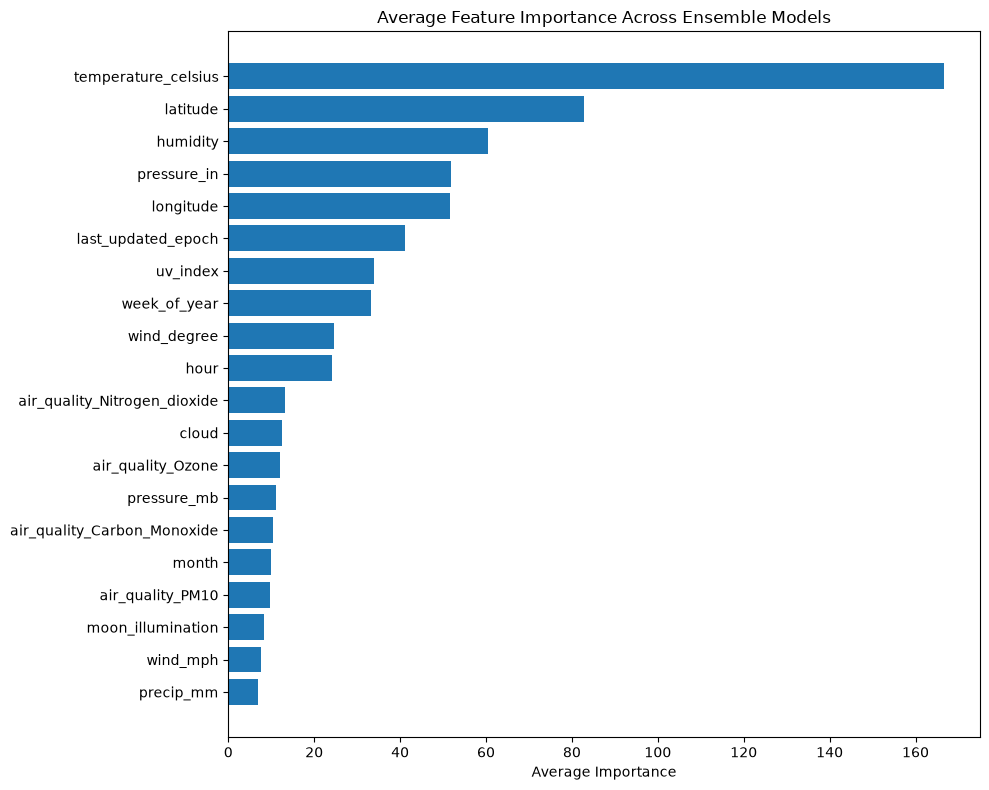

In [36]:
plt.figure(figsize=(10,8))

plt.barh(
    combined_importance["Feature"][:20][::-1],
    combined_importance["Average Importance"][:20][::-1],
)

plt.title(
    "Average Feature Importance Across Ensemble Models"
)

plt.xlabel(
    "Average Importance"
)

plt.tight_layout()

plt.show()

### Discussion

The comparison of feature importance across Random Forest, XGBoost, LightGBM, and CatBoost demonstrates a high degree of consistency among the ensemble learning algorithms.

Several engineered weather variables were repeatedly identified as important predictors across multiple models, indicating that these features provide robust predictive information for short-term temperature forecasting.

The agreement observed among independent ensemble methods increases confidence that the identified variables are genuinely informative rather than artifacts of a single learning algorithm.

Overall, the feature importance analysis confirms that the feature engineering process successfully generated meaningful temporal and meteorological predictors that substantially contributed to forecasting performance.